# The Financial Landscape of Tech: A 2025 Analysis of Salaries and Roles

**Source:** [Kaggle – Salaries for Data Science Jobs](https://www.kaggle.com/datasets/adilshamim8/salaries-for-data-science-jobs)

The tech industry has seen explosive growth in Data Science, AI, and Machine Learning roles over the past five years. This dataset captures that evolution through over 150,000 salary records. By analyzing it, we can uncover trends in compensation, identify which job titles command the highest pay, and explore how variables such as experience level, employment type, remote work, and company size shape salaries across the globe.

## Dataset Overview 

#### 1. Basic Data Exploration
Below we load the dataset, display the first and last five rows, check the shape, and list the column names.

In [3]:
# Importing required libraries

import numpy as np
import pandas as pd

In [4]:
# Reading the csv file and creating a dataframe
df = pd.read_csv("salaries.csv")

In [5]:
print('First Five Rows:')
df.head()

First Five Rows:


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,EX,FT,Head of Data,348516,USD,348516,US,0,US,M
1,2025,EX,FT,Head of Data,232344,USD,232344,US,0,US,M
2,2025,SE,FT,Data Scientist,145400,USD,145400,US,0,US,M
3,2025,SE,FT,Data Scientist,81600,USD,81600,US,0,US,M
4,2025,MI,FT,Engineer,160000,USD,160000,US,100,US,M


In [6]:
print('Last Five Rows:')
df.tail()

Last Five Rows:


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
151440,2020,SE,FT,Data Scientist,412000,USD,412000,US,100,US,L
151441,2021,MI,FT,Principal Data Scientist,151000,USD,151000,US,100,US,L
151442,2020,EN,FT,Data Scientist,105000,USD,105000,US,100,US,S
151443,2020,EN,CT,Business Data Analyst,100000,USD,100000,US,100,US,L
151444,2021,SE,FT,Data Scientist,7000000,INR,94665,IN,50,IN,L


In [7]:
rows, columns = df.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {columns}")

Number of rows: 151445
Number of columns: 11


In [8]:
list(df.columns)

['work_year',
 'experience_level',
 'employment_type',
 'job_title',
 'salary',
 'salary_currency',
 'salary_in_usd',
 'employee_residence',
 'remote_ratio',
 'company_location',
 'company_size']

**Observations:**
- The dataset contains **151,445 rows** and **11 columns**.
- Each row represents a single salary report for a Data Science / AI / ML professional.
- The 11 columns are: work_year, experience_level, employment_type, job_title, salary, salary_currency, salary_in_usd, employee_residence, remote_ratio, company_location, and company_size.
- The data spans from year 2020 to 2025, with the head showing 2025 entries and the tail showing 2020–2021 entries.

#### 2. Data Types and Structure
Using df.info()to display data types and then identifying numerical vs. categorical columns.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151445 entries, 0 to 151444
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   work_year           151445 non-null  int64 
 1   experience_level    151445 non-null  object
 2   employment_type     151445 non-null  object
 3   job_title           151445 non-null  object
 4   salary              151445 non-null  int64 
 5   salary_currency     151445 non-null  object
 6   salary_in_usd       151445 non-null  int64 
 7   employee_residence  151445 non-null  object
 8   remote_ratio        151445 non-null  int64 
 9   company_location    151445 non-null  object
 10  company_size        151445 non-null  object
dtypes: int64(4), object(7)
memory usage: 12.7+ MB


In [10]:
print('Numerical Columns: ')
for column in df.columns:
    if df[column].dtypes == 'int64':
        print(column)

Numerical Columns: 
work_year
salary
salary_in_usd
remote_ratio


In [11]:
print('Categorical Columns: ')
for column in df.columns:
    if df[column].dtypes == 'object':
        print(column)

Categorical Columns: 
experience_level
employment_type
job_title
salary_currency
employee_residence
company_location
company_size


**Observations (Data Types and Structure):**

**Numerical columns (int64):** work_year, salary, salary_in_usd, remote_ratio

**Categorical columns (object):** experience_level, employment_type, job_title, salary_currency, employee_residence, company_location, company_size

**Should any data types be converted?**
- remote_ratio is technically numerical, but it only takes three discrete values (0, 50, 100), so it behaves more like a categorical variable representing none, hybrid, or fully remote work.

#### 3. Descriptive Summary
Generating summary statistics for the numerical columns using `df.describe()`.

In [12]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,151445.000000,1.514450e+05,151445.000000,151445.000000
mean,2024.435313,1.628380e+05,157527.458411,20.938625
std,0.671842,2.080124e+05,74150.772377,40.620393
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2024.000000,1.060000e+05,105800.000000,0.000000
50%,2025.000000,1.470000e+05,146100.000000,0.000000
75%,2025.000000,1.990000e+05,198000.000000,0.000000
max,2025.000000,3.040000e+07,800000.000000,100.000000


**Interpretation of Summary Statistics:**

- **salary_in_usd:** The mean salary is approximately **\$157,527** with a standard deviation of **\$74,151**, indicating considerable spread. The minimum is 15,000 USD and the maximum is 800,000 USD. The median (50th percentile) is 146,100 USD which suggests the distribution is right-skewed. The interquartile range (105,800 USD to 198,000 USD) captures the middle half of salaries.

- **salary (in original currency):** The mean is roughly \$162,838 but the max is \$30,400,000. This extreme maximum likely comes from salaries reported in currencies like INR or other non-USD currencies, which appear very large before conversion. This column is less useful for comparison; salary_in_usd is the standardized measure.

- **remote_ratio:** The mean is about **20.9**, and the 75th percentile is **0**, meaning the vast majority of roles are on-site (remote_ratio = 0). Only a fraction are hybrid (50) or fully remote (100).

- **work_year:** The mean is around 2024.4, confirming that most records come from the 2024–2025 period.

**Unusual values:** The salary column has an extremely large max value (30,400,000) compared to salary_in_usd (800,000). This is not an error, it reflects salaries reported in other currencies like INR. The salary_in_usd column normalizes this correctly.

#### 4. Missing or Duplicate Data
Checking for null values in each column, counting duplicate rows, and displaying the duplicates.

In [13]:
df.isnull().sum()

work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [14]:
print("Number of duplicated values:")
print(df.duplicated().sum())

Number of duplicated values:
79532


In [15]:
df[df.duplicated()]

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
14,2025,SE,FT,Manager,230000,USD,230000,US,0,US,M
15,2025,SE,FT,Manager,121000,USD,121000,US,0,US,M
16,2025,SE,FT,Manager,230000,USD,230000,US,0,US,M
17,2025,SE,FT,Manager,121000,USD,121000,US,0,US,M
18,2025,SE,FT,Manager,230000,USD,230000,US,0,US,M
...,...,...,...,...,...,...,...,...,...,...,...
151148,2022,SE,FT,Data Engineer,115000,USD,115000,US,100,US,M
151233,2021,MI,FT,Data Scientist,150000,USD,150000,US,100,US,M
151287,2021,MI,FT,Data Engineer,200000,USD,200000,US,100,US,L
151367,2021,EN,FT,Data Scientist,90000,USD,90000,US,100,US,S


**Observations:**

- **Missing values:** There are **zero missing values** across all 11 columns. The dataset is fully complete, which means no imputation is needed.

- **Duplicate rows:** There are **79,532 duplicate rows** (about 52.5% of the dataset). This is a very high proportion. These duplicates are likely legitimate — multiple people can hold the same job title, at the same experience level, at a same-sized company, in the same country, and earn the same salary. Since each row represents an individual salary report and there is no unique identifier column, identical rows do not necessarily mean data entry errors. However, for some analyses (e.g., counting unique job postings), it may be appropriate to drop duplicates.

---
## Data Wrangling

We are creating one derived column: <br>
**is_ml_role**. This is a boolean value indicating whether the job title contains AI/ML keywords (e.g., "Machine Learning", "AI", "Deep Learning").

In [16]:
ml_keywords = ['Machine Learning', 'ML', 'AI', 'Artificial Intelligence', 'Deep Learning']
df['is_ml_role'] = df['job_title'].apply(lambda title: any(keyword in title for keyword in ml_keywords))

df[['job_title', 'is_ml_role']].head()

,job_title,is_ml_role
0,Head of Data,False
1,Head of Data,False
2,Data Scientist,False
3,Data Scientist,False
4,Engineer,False


**Explanation:**
The **is_ml_role** column is a boolean flag (True/False) that checks if a job title contains any AI or Machine Learning keyword. This lets us quickly isolate and compare ML/AI-specific roles against the rest of the dataset.


#### 7. Filtering the Data
We apply two filters:
1. **Filter 1:** Entry-level ML/AI roles (is_ml_role == True and experience_level == 'EN') — to see what newcomers to ML earn.
2. **Filter 2:** Selecting key columns (job_title, company_size, salary_in_usd) from the filtered data — to focus on which company sizes hire entry-level ML talent and how much they pay.

In [17]:
entry_ml_df = df[(df['is_ml_role'] == True) & (df['experience_level'] == 'EN')]
entry_ml_df

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,is_ml_role
466,2025,EN,FT,AI Engineer,70000,USD,70000,US,100,US,M,True
467,2025,EN,FT,AI Engineer,60000,USD,60000,US,100,US,M,True
1280,2025,EN,FT,Machine Learning Engineer,300000,USD,300000,US,0,US,M,True
1281,2025,EN,FT,Machine Learning Engineer,210000,USD,210000,US,0,US,M,True
3763,2025,EN,FT,Artificial Intelligence Engineer,105000,USD,105000,US,0,US,M,True
...,...,...,...,...,...,...,...,...,...,...,...,...
151347,2021,EN,FT,Machine Learning Engineer,21000,EUR,24823,DE,50,DE,M,True
151354,2021,EN,FT,Machine Learning Engineer,21844,USD,21844,CO,50,CO,M,True
151365,2021,EN,FT,Machine Learning Engineer,81000,USD,81000,US,50,US,S,True
151393,2020,EN,FT,AI Scientist,300000,DKK,45896,DK,50,DK,S,True


In [18]:
entry_ml_df[['job_title', 'company_size', 'salary_in_usd']].head()

,job_title,company_size,salary_in_usd
466,AI Engineer,M,70000
467,AI Engineer,M,60000
1280,Machine Learning Engineer,M,300000
1281,Machine Learning Engineer,M,210000
3763,Artificial Intelligence Engineer,M,105000


**Explanation:** The first filter narrows the 151,445 records down to only **623 rows** — entry-level (EN) professionals in ML/AI roles. This is a small but interesting subset. The second filter focuses on just the job title, company size, and USD salary columns so we can quickly see which types of companies are hiring these entry-level ML professionals and at what pay level. From the first few rows, entry-level AI Engineers at mid-sized (M) companies earn around \$60,000–\$70,000, while entry-level Machine Learning Engineers can earn up to \$300,000, showing significant salary variation even within entry-level ML roles.

#### 8. Unique Values and Categories
Listing the unique job titles within the entry-level ML/AI subset to understand the variety of roles.

In [19]:
list(entry_ml_df['job_title'].unique())

['AI Engineer',
 'Machine Learning Engineer',
 'Artificial Intelligence Engineer',
 'AI Researcher',
 'Machine Learning Researcher',
 'AI Scientist',
 'Machine Learning Scientist',
 'AI Developer',
 'AI Content Writer',
 'AI Specialist',
 'ML Scientist',
 'AI Programmer',
 'AI Research Scientist',
 'AI Machine Learning Engineer',
 'Machine Learning Specialist',
 'Machine Learning Developer',
 'AI Data Engineer',
 'AI Data Scientist',
 'Machine Learning Model Engineer',
 'AI Research Engineer',
 'AI Software Engineer',
 'MLOps Engineer',
 'Machine Learning Research Engineer',
 'Applied Machine Learning Scientist',
 'Deep Learning Engineer']

**Observations (Unique Values):**
- There are **25 unique ML/AI job titles** in the entry-level subset, including: AI Engineer, Machine Learning Engineer, Artificial Intelligence Engineer, AI Researcher, ML Scientist, Deep Learning Engineer, MLOps Engineer, and others.
- The most important categorical variables for analysis or grouping are:
  - **experience_level** — to compare salaries across entry, mid, senior, and executive levels.
  - **company_size** — to see how small, medium, and large companies differ in compensation.
  - **job_title** — categorical data useful for comparing specific roles.
  - **employment_type** — to analyze differences between full-time, contract, part-time, and freelance roles.

#### 10. Grouping and Aggregation
Grouping the entry-level ML/AI roles by **company_size** to calculate the **average salary (USD)** and the **number of jobs** in each group.

In [20]:
ml_salary_by_size = entry_ml_df.groupby('company_size')['salary_in_usd'].agg(['mean', 'count']).reset_index()
ml_salary_by_size = ml_salary_by_size.rename(columns={'mean': 'avg_salary_usd', 'count': 'number_of_jobs'})
ml_salary_by_size = ml_salary_by_size.sort_values(by='avg_salary_usd', ascending=False)

In [21]:
ml_salary_by_size

,company_size,avg_salary_usd,number_of_jobs
1,M,138346.720641,562
0,L,91960.138889,36
2,S,60785.120000,25


**Interpretation of Grouped Results:**

- **Medium-sized companies** dominate the hiring of entry-level ML/AI professionals (562 out of 623), and they also offer the highest average salary (around $138K).
- **Large companies** have far fewer entry-level ML hires (only 36) and pay a lower average (around $92K). This could indicate that large companies have more structured pay bands or hire entry-level ML roles in lower-cost regions.
- **Small companies** pay the least on average (around $61K) with only 25 hires, possibly reflecting budget constraints or hiring in lower-cost-of-living areas.

---
## Summary and Conclusion

This dataset provides a rich and comprehensive look at the Data Science, AI, and Machine Learning job market from 2020 to 2025. Here are the key takeaways from this initial exploration:

- **Scale:** With over 151,000 salary records across 11 features and six years. This is a sizable dataset that enables meaningful analysis of compensation trends in the tech industry.

- **Data quality:** The dataset has no missing values and consistent categorical encodings. However, about 52% of the rows are duplicates, which is expected given the lack of a unique identifier. Many professionals share the same combination of attributes.

- **Salary distribution:** The average salary in USD is approximately 157,500 USD. A small number of very high earners pull the mean above the median (146,100 USD). Salaries ranges from 15,000 USD to 800,000 USD.

- **Remote work:** The majority of positions are on-site, with remote and hybrid roles making up a smaller portion.

- **ML/AI focus:** Only about 623 entry-level ML/AI roles exist in the dataset, and medium-sized companies are the primary employers for these positions, offering significantly higher average salaries compared to large and small companies.

- **Questions for further exploration:** How have salaries changed year over year? Do fully remote roles pay more or less than on-site? Which specific job titles command the highest compensation?

## Data Visualization

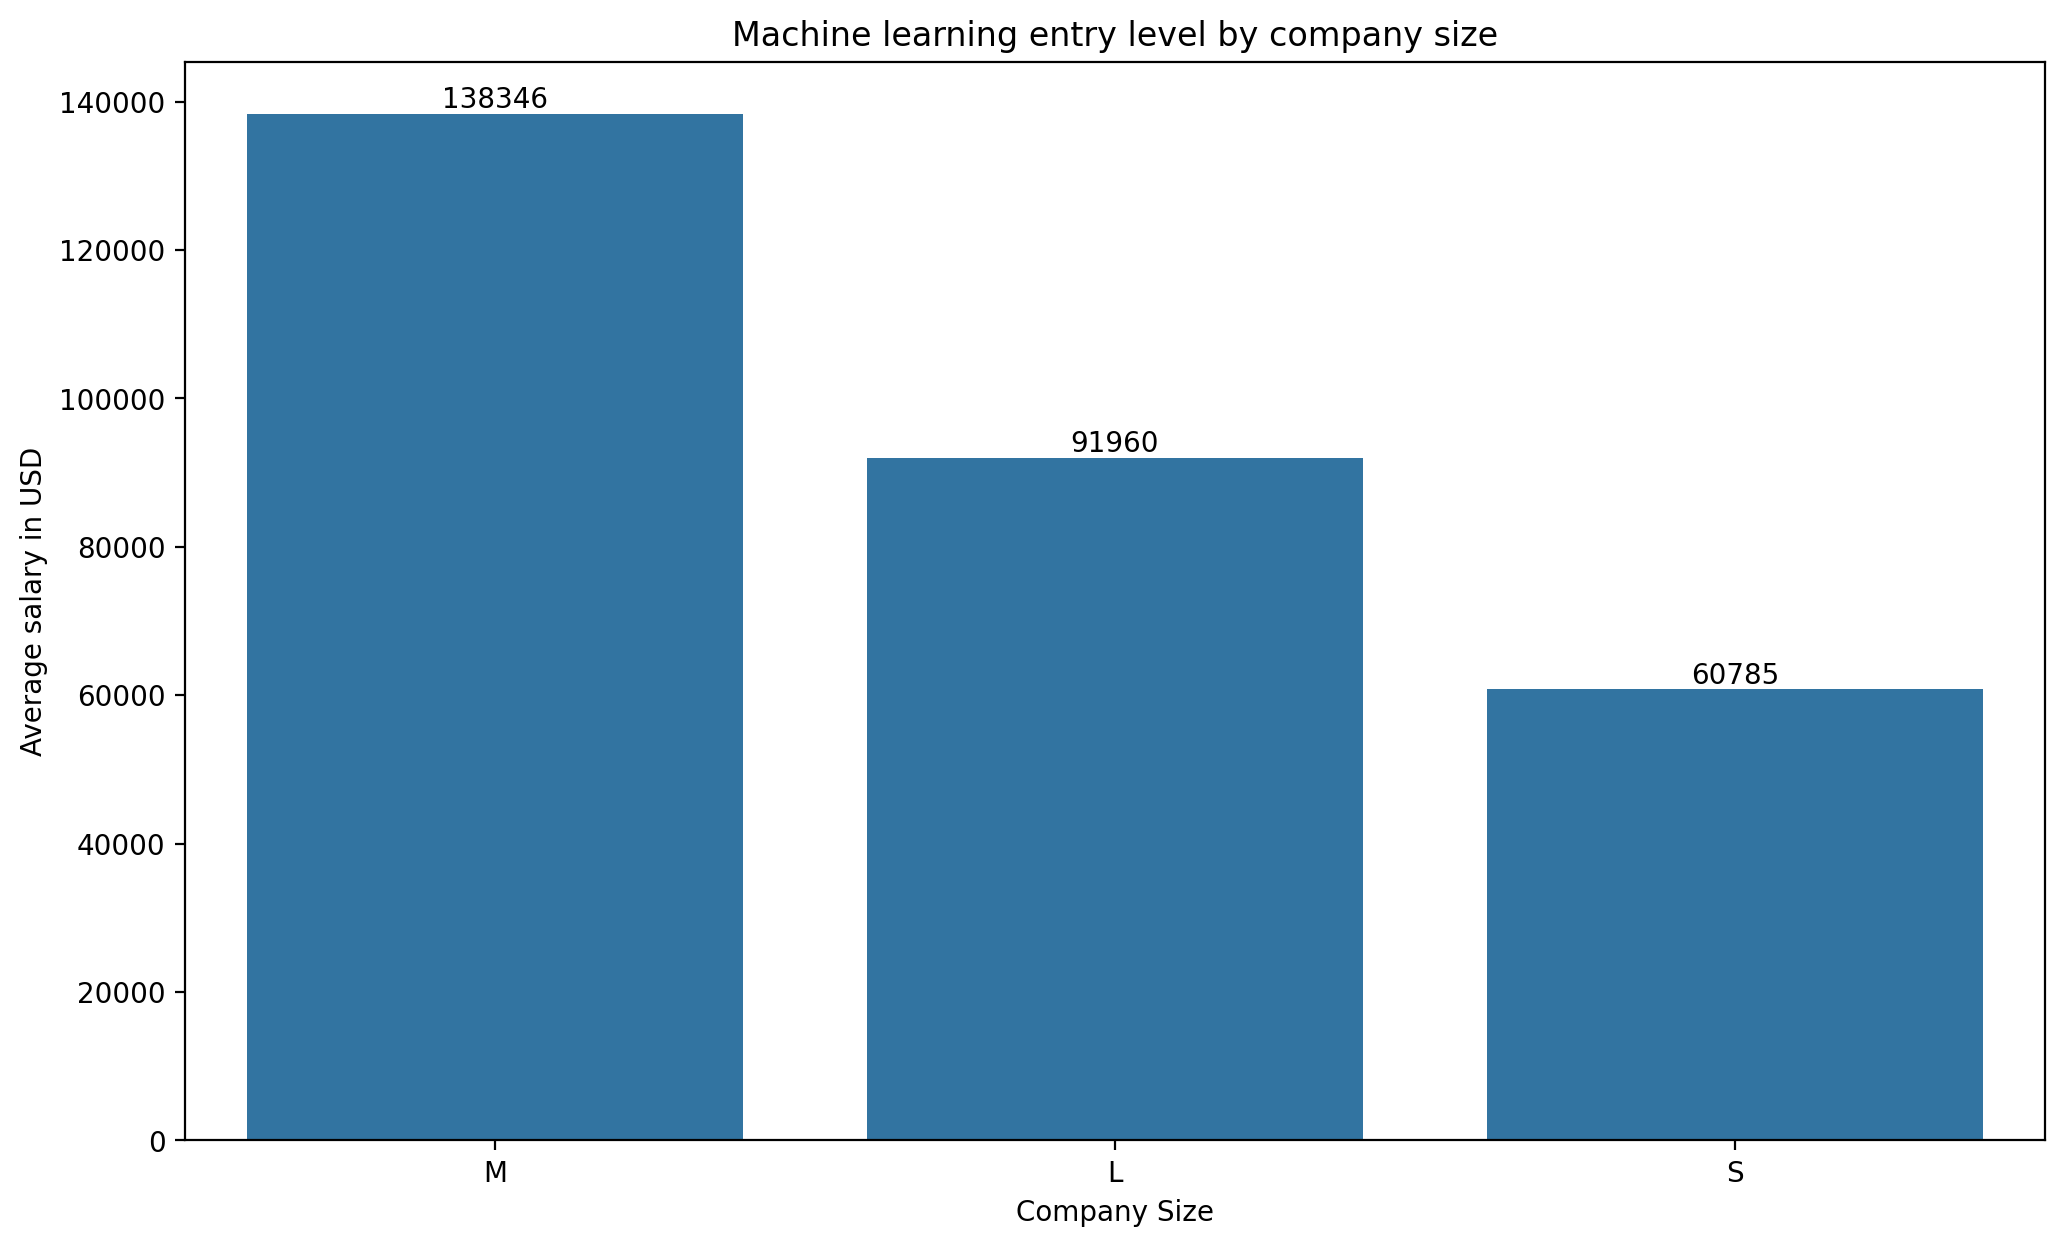

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
ax = sns.barplot(x=ml_salary_by_size['company_size'], y = ml_salary_by_size['avg_salary_usd'])
plt.title('Machine learning entry level by company size')
plt.xlabel('Company Size')
plt.ylabel('Average salary in USD')
for i, v in enumerate(ml_salary_by_size['avg_salary_usd']):
    ax.text(i, v+1, str(int(v)), ha='center', va="bottom")
plt.show()

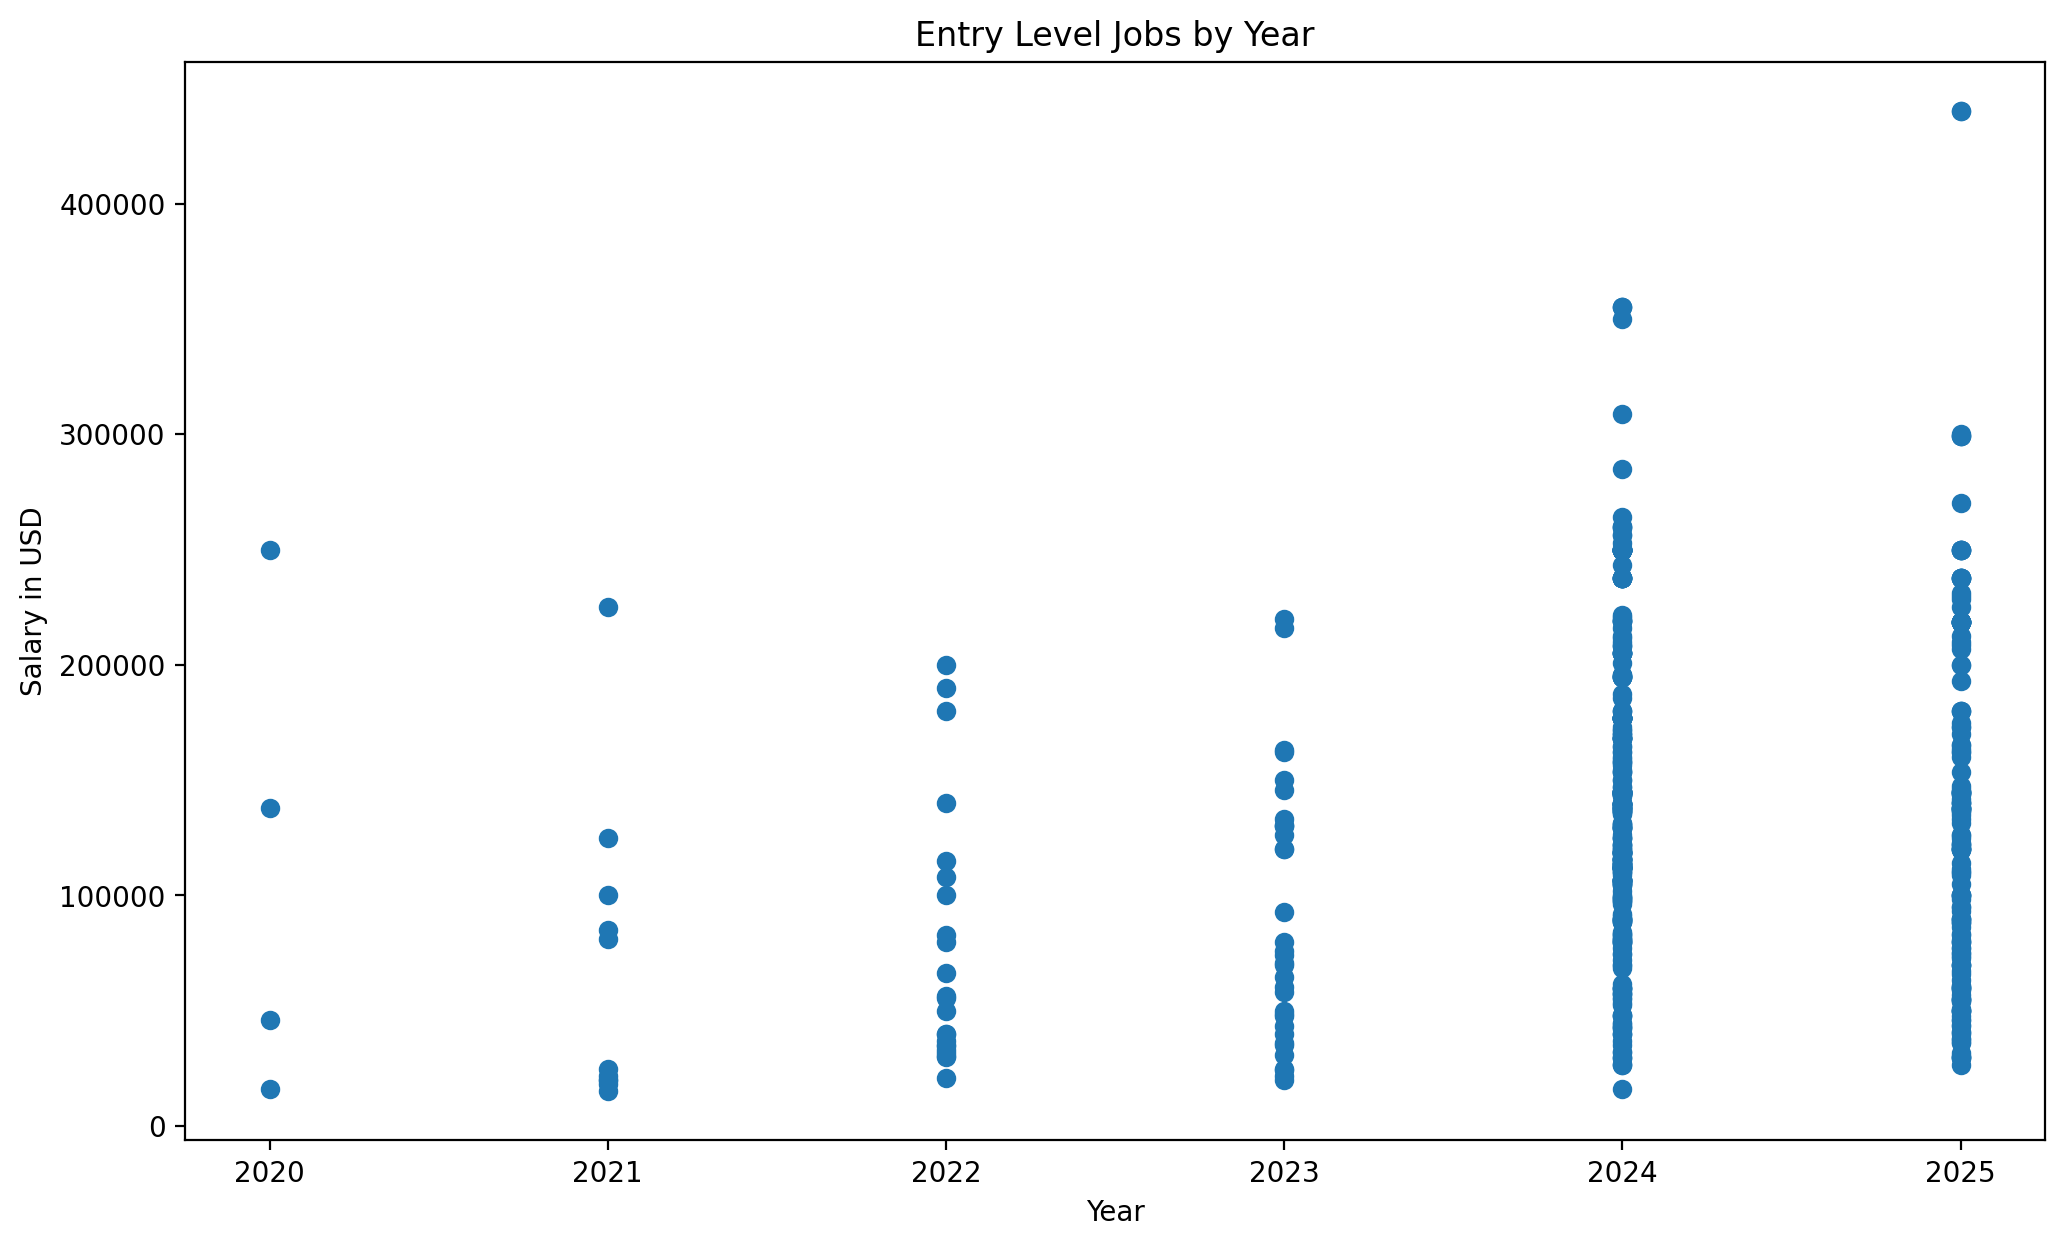

In [30]:
plt.scatter(entry_ml_df['work_year'], entry_ml_df['salary_in_usd'])
plt.title('Entry Level Jobs by Year')
plt.xlabel('Year')
plt.ylabel('Salary in USD')
plt.show()

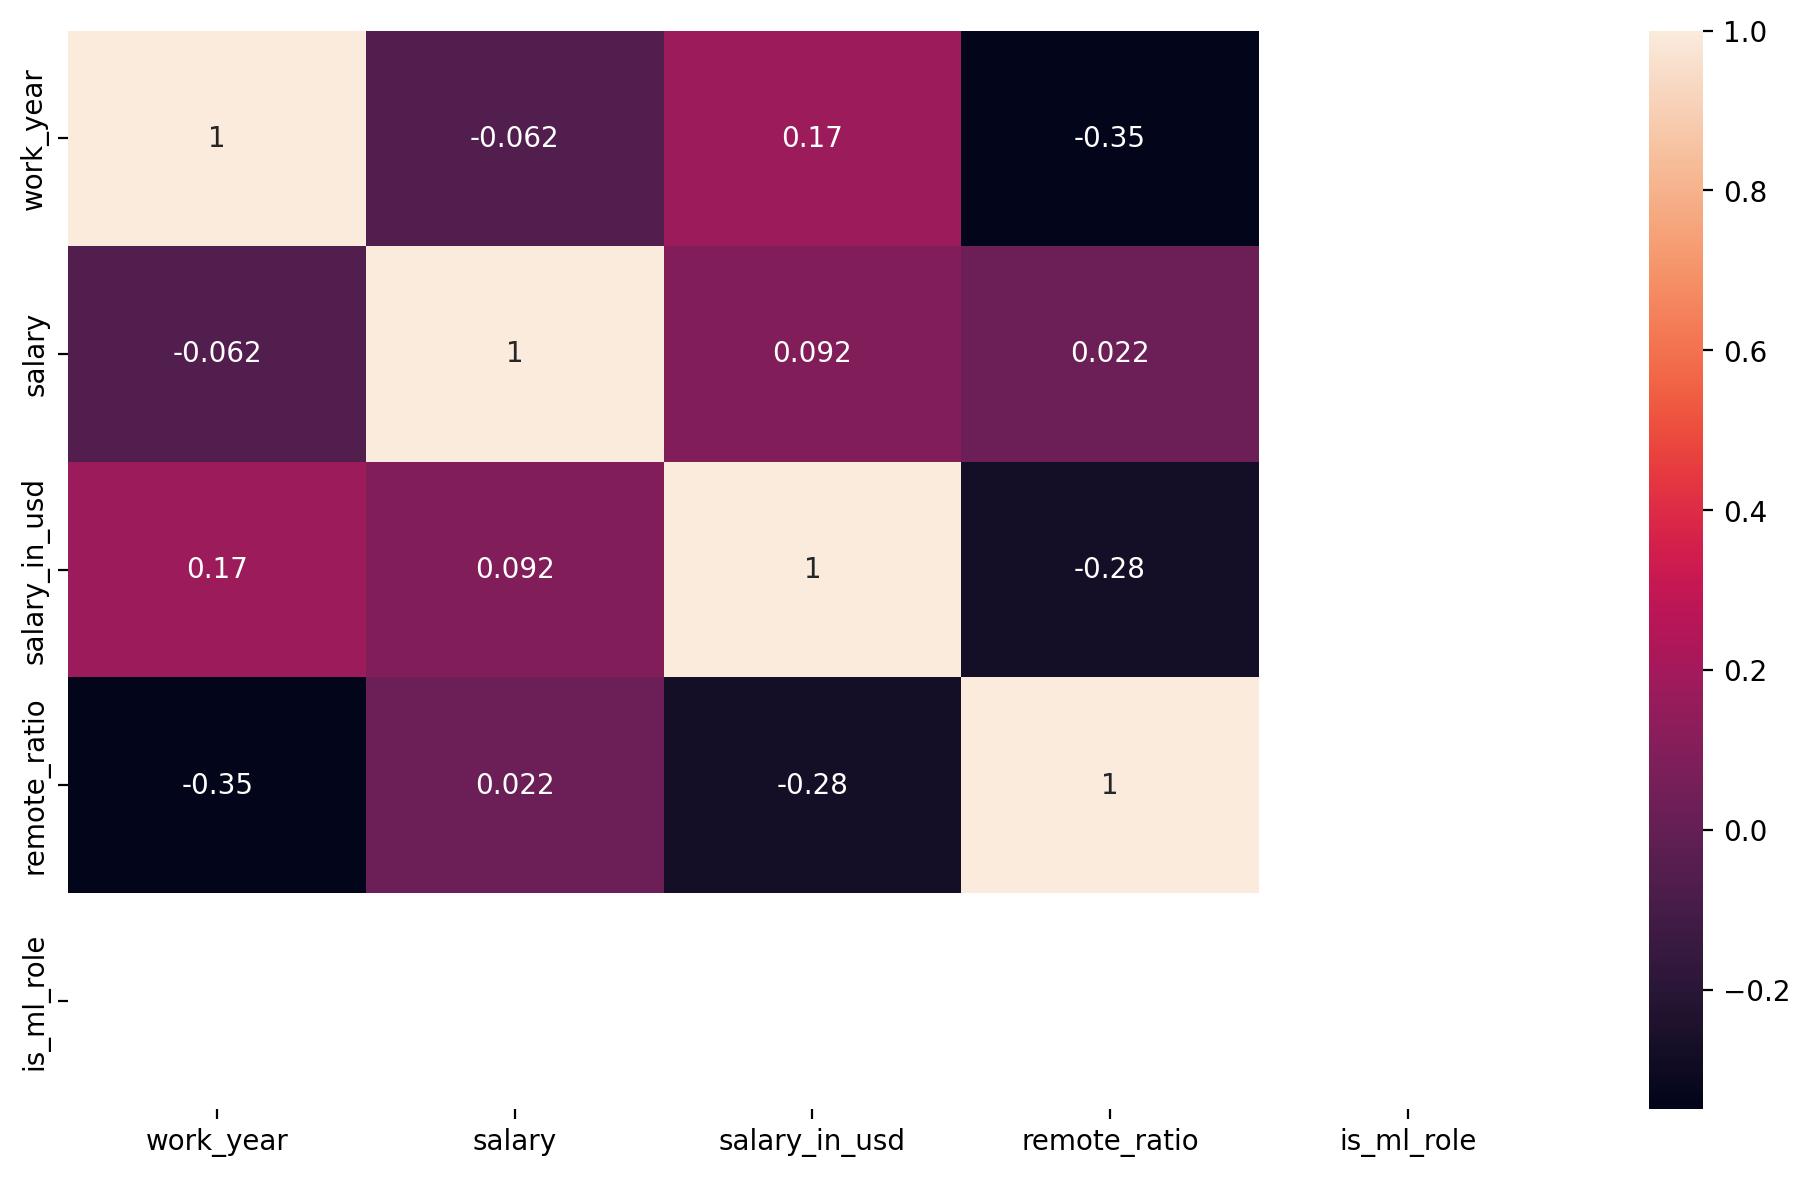

In [31]:
corr_matrix = entry_ml_df.corr(numeric_only = True)
sns.heatmap(corr_matrix, annot = True)
plt.show()